# klastering email

In [1]:
!pip install plotly


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
!pip install -q nltk contractions emoji pyspellchecker Sastrawi


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
!pip install gensim



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
import re
import sys
import time
import string
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from spellchecker import SpellChecker
import contractions
import emoji
from gensim.models import Word2Vec, FastText
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm
warnings.filterwarnings('ignore')

In [5]:
nltk.download("punkt")
nltk.download("punkt_tab")

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
berita = pd.read_csv("spam.csv", dtype=str, encoding="utf-8", encoding_errors="ignore").fillna("")
berita.head()


,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",,,
1,2,Ok lar... Joking wif u oni...,,,
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,,,
3,4,U dun say so early hor... U c already then say...,,,
4,5,"Nah I don't think he goes to usf, he lives aro...",,,


In [15]:
import string

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = emoji.demojize(text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\W', ' ', text)
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [16]:
df_raw = pd.read_csv(
    "spam.csv",
    header=None,
    encoding="latin1",
    on_bad_lines="skip"
)

# ambil hanya dua kolom pertama: id + text
df = pd.DataFrame({
    "id": df_raw.iloc[:, 0],
    "Text": df_raw.iloc[:, 1]
})

# hapus baris kosong
df = df.dropna(subset=["Text"])

df.head()

,id,Text
0,id,Text
1,1,"Go until jurong point, crazy.. Available only ..."
2,2,Ok lar... Joking wif u oni...
3,3,Free entry in 2 a wkly comp to win FA Cup fina...
4,4,U dun say so early hor... U c already then say...


In [17]:
df["Clean"] = df["Text"].apply(clean_text)
df.head()


,id,Text,Clean
0,id,Text,text
1,1,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
2,2,Ok lar... Joking wif u oni...,ok lar joking wif u oni
3,3,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
4,4,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say


In [18]:
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df["Clean"])
X.shape


(5573, 8296)

In [21]:
df.to_csv("hasil_preprocessing_emailUTS.csv", index=False)


In [22]:
# Memuat Dataset
try:
    df = pd.read_csv('hasil_preprocessing_emailUTS.csv')
    print(f"\nDataset berhasil dimuat. Jumlah data: {len(df)} baris.")
    print("Contoh data awal:")
    print(df.head())
except FileNotFoundError:
    print("\nError: File tidak ditemukan. Pastikan nama file CSV sudah benar.")
    # Jika file tidak ditemukan, hentikan proses.
    # df = pd.DataFrame()


Dataset berhasil dimuat. Jumlah data: 5573 baris.
Contoh data awal:
   id                                               Text  \
0  id                                               Text   
1   1  Go until jurong point, crazy.. Available only ...   
2   2                      Ok lar... Joking wif u oni...   
3   3  Free entry in 2 a wkly comp to win FA Cup fina...   
4   4  U dun say so early hor... U c already then say...   

                                               Clean  
0                                               text  
1  go until jurong point crazy available only in ...  
2                            ok lar joking wif u oni  
3  free entry in a wkly comp to win fa cup final ...  
4        u dun say so early hor u c already then say  


In [24]:
def safe_tokenize(text):
    if not isinstance(text, str):
        text = ""  
    return word_tokenize(text)

df['tokens'] = df['Clean'].apply(safe_tokenize)
print(f"Data bersih dimuat. Jumlah data: {len(df)} baris.")


Data bersih dimuat. Jumlah data: 5573 baris.


In [ ]:
from gensim.corpora import Dictionary
from gensim.models import HdpModel, LdaMulticore
import time
import matplotlib.pyplot as plt
import numpy as np
from gensim.models.coherencemodel import CoherenceModel

# Pastikan tidak ada dokumen kosong
documents = [doc for doc in df['tokens'].tolist() if len(doc) > 0]

print(f"Jumlah dokumen valid: {len(documents)}")

# Buat dictionary
dictionary = Dictionary(documents)

# Filter extremes SESUAI dataset kecil
dictionary.filter_extremes(no_below=2, no_above=0.9)

# Buat corpus
corpus = [dictionary.doc2bow(doc) for doc in documents]

print(f"\nKamus dibuat. Jumlah kata unik setelah filter: {len(dictionary)}")

# ===== HDP untuk estimasi topik =====
print("\n--- Menjalankan HDP untuk estimasi jumlah topik... ---")

hdp_model = HdpModel(corpus=corpus, id2word=dictionary)

# Ambil topik yang non-empty
hdp_topics = hdp_model.print_topics()

estimated_num_topics = len(hdp_topics)

print(f"Perkiraan kasar jumlah topik dari HDP: {estimated_num_topics}")


# ===== CARI JUMLAH TOPIK TERBAIK =====
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    for num_topics in range(start, limit, step):
        model = LdaMulticore(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=8,
            random_state=42,
            workers=1  # aman untuk semua device
        )
        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())
        print(f"Jumlah topik: {num_topics} | Koherensi: {coherence_values[-1]:.4f}")
    return coherence_values

# Range pencarian disesuaikan data kecil
search_start = 2
search_limit = min(estimated_num_topics + 4, 15)  # batas aman
search_step = 1

print(f"\nSearching topik dari {search_start} sampai {search_limit}...")

coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=documents,
    start=search_start,
    limit=search_limit,
    step=search_step
)

x = range(search_start, search_limit, search_step)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x, coherence_values, marker='o')
plt.xlabel('Jumlah Topik')
plt.ylabel('Koherensi (c_v)')
plt.grid(True)
plt.title("Pencarian Jumlah Topik Optimal")
plt.show()

optimal_num_topics = x[np.argmax(coherence_values)]
print(f"\n🔥 Jumlah topik optimal: {optimal_num_topics}")


# ===== LDA FINAL =====
print("\n--- Melatih LDA final... ---")

lda_model = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_num_topics,
    passes=15,
    random_state=42,
    workers=1
)

print("\n--- Topik yang ditemukan ---")
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"\nTopik {idx}: {topic}")


# ===== EKSTRAK FITUR TOPIK =====
def get_lda_features(lda_model, bow_corpus, n_topics):
    features = []
    for doc_bow in bow_corpus:
        dist = lda_model.get_document_topics(doc_bow, minimum_probability=0)
        vector = [0.0] * n_topics
        for topic_id, prob in dist:
            vector[topic_id] = prob
        features.append(vector)
    return np.array(features)

X = get_lda_features(lda_model, corpus, optimal_num_topics)

print("\nEkstraksi fitur selesai!")
print(f"Bentuk matriks fitur X: {X.shape}")



--- Mencari K Optimal dengan Silhouette Score (Metode Kuantitatif) ---
Untuk K = 2, Silhouette Score-nya adalah 0.0029
Untuk K = 3, Silhouette Score-nya adalah 0.0040
Untuk K = 4, Silhouette Score-nya adalah 0.0046
Untuk K = 5, Silhouette Score-nya adalah 0.0060
Untuk K = 6, Silhouette Score-nya adalah 0.0063
Untuk K = 7, Silhouette Score-nya adalah 0.0090
Untuk K = 8, Silhouette Score-nya adalah 0.0093
Untuk K = 9, Silhouette Score-nya adalah 0.0101
Untuk K = 10, Silhouette Score-nya adalah 0.0106
Untuk K = 11, Silhouette Score-nya adalah 0.0116
Untuk K = 12, Silhouette Score-nya adalah 0.0125
Untuk K = 13, Silhouette Score-nya adalah 0.0130
Untuk K = 14, Silhouette Score-nya adalah 0.0130
Untuk K = 15, Silhouette Score-nya adalah 0.0139


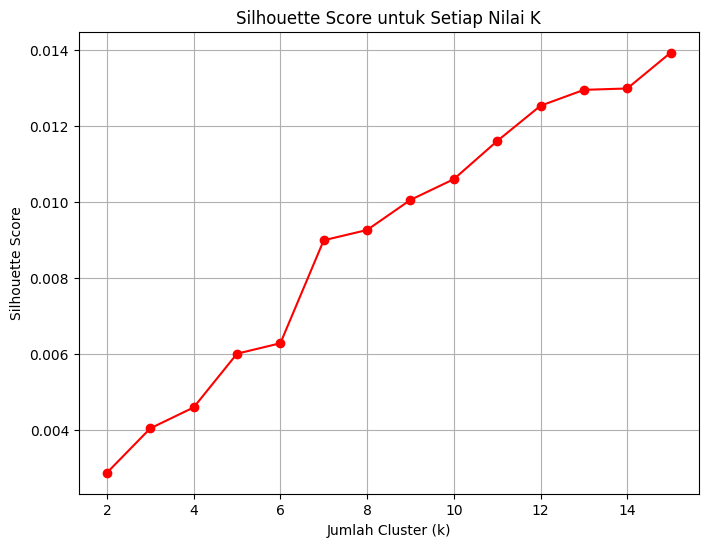


✅ Berdasarkan Silhouette Score, K terbaik adalah: 15

--- Menjalankan K-Means final dengan K=15... ---

Contoh email dari setiap cluster yang ditemukan:

----- CLUSTER 0 -----
- U dun say so early hor... U c already then say......
- Nah I don't think he goes to usf, he lives around here though...

----- CLUSTER 1 -----
- Oops, I'll let you know when my roommate's done...
- Great! I hope you like your man well endowed. I am  &lt;#&gt;  inches......

----- CLUSTER 2 -----
- Sorry, I'll call later in meeting....
- Sorry, I'll call later...

----- CLUSTER 3 -----
- WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only....
- URGENT! You have won a 1 week FREE membership in our å£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18...

----- CLUSTER 4 -----
- Go until jurong point, crazy.. Available only in bugis n great world la e buffet..

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Menemukan K Optimal dengan Silhouette Score
print("\n--- Mencari K Optimal dengan Silhouette Score (Metode Kuantitatif) ---")
K_range = range(2, 16)
silhouette_scores = []
for k in K_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X)
    score = silhouette_score(X, kmeans_model.labels_)
    silhouette_scores.append(score)
    print(f"Untuk K = {k}, Silhouette Score-nya adalah {score:.4f}")

# Visualisasikan hasilnya
plt.figure(figsize=(8, 6)) # Ukuran plot disesuaikan
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Setiap Nilai K')
plt.grid(True)
plt.show()

# Jalankan K-Means dengan K Terbaik
# Pilih K yang memberikan Silhouette Score TERTINGGI secara otomatis
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✅ Berdasarkan Silhouette Score, K terbaik adalah: {optimal_k}")


# Latih Model K-Means Final & Analisis Hasil ---
print(f"\n--- Menjalankan K-Means final dengan K={optimal_k}... ---")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
# Ganti 'df' dengan nama DataFrame yang berisi data bersih Anda
df['cluster'] = kmeans.fit_predict(X)

# Analisis Hasil Cluster ---
print("\nContoh email dari setiap cluster yang ditemukan:")
for i in range(optimal_k):
    print(f"\n----- CLUSTER {i} -----")
    sample_emails = df[df['cluster'] == i]['Text'].head(2).tolist()
    for email_text in sample_emails:
        print(f"- {str(email_text)[:250]}...")

print("\n✅ Proses clustering selesai.")